# First MVP RL

# MDP Formulation
Zustandsraum S = (b_t, t):
S = (b_t, t)
b_t ∈ [0, 50] kWh -> Batteriestand
t ∈ {0, 1, ..., 8} -> Zeitschritt (0 = 14:00, 8 = 16:00)

Begründung: Beide Variablen erfüllen die Markov-Eigenschaft. Der Agent braucht nur den aktuellen Batteriestand und die verbleibende Zeit, um eine optimale Entscheidung zu treffen.

Aktionsraum A = {0, 7.33, 14.67, 22} kWh
Begründung: Gleichmäßige Abstufung für zero, low, medium, high

Transitionsfunktion P
Phase A (t < 8) – deterministisch:
P^a_ss' = P[S_t = s' | S_{t-1} = s, A_{t-1} = a] = 1
für s' = (min(b_t + a·0.25, 50), t+1)

Phase B – stochastisch (t = 8):
D ~ N(μ=30, σ=5) kWh,  aufgedeckt bei Abfahrt

Begründung: Die Physik des Ladens ist eindeutig bestimmt. Gegeben Batteriestand und Ladeleistung gibt es genau einen möglichen Folgezustand, daher p = 1. Das min(...) stellt sicher, dass die Batterie nie über B_max = 50 kWh geladen wird. Erst bei t = 8 entsteht echte Stochastizität durch den zufälligen Energiebedarf D, den der Agent während des Ladens nicht kennt. Siehe Aufgabentext:
“The energy demand is a stochastic value following a normal distribution (you should choose the parameters, e.g., 𝜇= 30 kWh, 𝜎 = 5 kWh) and must be generated exactly when the driver wants to leave.”

Reward-Funktion R
Während des Ladens (t = 0,...,7):
R_t = -α_t · e^(a_t)
Bei Abfahrt (t = 8):
R_8 = -500 falls b_8 < D
R_8 = 0 sonst

Begründung: Die Kostenfunktion während des Ladens ist in der Aufgabenstellung gegeben. Das Penalty von -500 bei Abfahrt ist von uns gegeben. Es muss getestet werden, was im Anwendungskontext als ausreichend „hoch“ gilt

In [2]:
import numpy as np
import random
from collections import defaultdict

# Class Environment

#TODO: Describe characteristics of ENV class, why we need it and how to use it.

In [3]:
CAPACITY = 50  # kWh
MAX_POWER = 22  # kW
TIME_INTERVALS = 8  # 2:00 PM to 4:00 PM in 15-min intervals
ACTION_SPACE = [0, 7.33, 14.67, 22]

class SmartChargingEnv:
    """
    Discrete event simulation for the EV charging problem.
    """
    def __init__(self, capacity=CAPACITY, max_power=MAX_POWER):
        self.capacity = capacity
        self.max_power = max_power
        
        # Actions
        self.action_space = ACTION_SPACE
        self.max_steps = TIME_INTERVALS
        
        # Environment state
        self.current_step = 0
        self.battery_level = 0.0
        
        # Time coefficients for cost (simulating variable electricity pricing)
        # The time coefficient α_t is assumed to be constant across all time steps, calibrated based on the average retail electricity price (transportation sector) for Illinois as reported by the U.S. Energy Information Administration (EIA, Retail Electricity Sales 2024, Table 9).
        # Ameren Illinois: 8.83 cents/kWh → 0.0883 $/kWh
        # (source: https://www.eia.gov/electricity/sales_revenue_price/pdf/table_9.pdf)
        self.alpha_t = [0.0883] * 8
        # TODO: alpha_t entweder unterschiedlich für jeden step oder konstant (vlt sogar probabilistisch)

    def reset(self):
        self.current_step = 0
        # Assume battery starts empty or at a random low value when arriving at 2 p.m.
        self.battery_level = 0.0 
        # TODO: Consider more realistic initial battery levels based on typical usage patterns
        # E.g. Start at 30% capacity
        # self.battery_level = random.uniform(0, self.capacity * 0.3)
        return self._get_state()

    def _get_state(self):
        # Discretize battery level to integer for basic Q-Learning compatibility
        return (self.current_step, int(self.battery_level))

    def step(self, action_idx):
        power_kw = self.action_space[action_idx]
        
        # Calculate new battery level (Power * 0.25 hours)
        #  s' = (min(b_t + a·0.25, 50), t+1)
        energy_added = power_kw * 0.25
        self.battery_level = min(self.capacity, self.battery_level + energy_added)
        
        # Calculate immediate charging cost (Exponential cost function)
        # R_t = -α_t · e^(a_t)
        alpha = self.alpha_t[self.current_step]
        # Using a normalized power value so math.exp doesn't blow up with 22kW
        power_normalized = power_kw / self.max_power  # 0 bis 1
        charging_cost = alpha * np.exp(power_normalized)
        reward = -charging_cost
        
        self.current_step += 1
        
        # Check termination and apply demand penalty
        done = False
        if self.current_step >= self.max_steps:
            done = True
            # Stochastic demand generation: Normal distribution (mu=30, sigma=5)
            # TODO: Consider more complex demand patterns based on time of day, weather, etc.
            demand = np.random.normal(30, 5)
            
            if self.battery_level < demand:
                # High penalty for running out of energy
                # TODO: Consider a more nuanced penalty based on how much energy is short
                reward -= 500

        return self._get_state(), reward, done

## Class Agent

#TODO: Describe characteristics of agent class, why we need it and how to use it.

In [4]:
LR = 0.1 # Learning rate
GAMMA = 1 # Discount factor
EPSILON = 0.1 # Exploration rate

class QLearningAgent:
    def __init__(self, action_space, lr=LR, gamma=GAMMA, epsilon=EPSILON):
        # Using a dictionary for the Q-table since states are tuples: (step, battery)
        self.q_table = defaultdict(lambda: np.zeros(len(action_space))) #Stores the learned ratings for each action and state during training
        self.action_space = action_space
        self.lr = lr
        self.gamma = gamma
        self.epsilon = epsilon

    # Epsilon-greedy action selection -> when random value below epsilon (exploration), when above (exploitation)
    def choose_action(self, state):
        if random.uniform(0, 1) < self.epsilon:
            return random.randint(0, len(self.action_space) - 1) #We take a random action from our action space
        return np.argmax(self.q_table[state]) #We take the best known value from our action space -> greedy policy

    # Q-learning update
    def learn(self, s, a, r, s_next, done):
        if done:
            td_target = r
        else:
            best_next_action = np.argmax(self.q_table[s_next])
            td_target = r + self.gamma * self.q_table[s_next][best_next_action]
            
        td_error = td_target - self.q_table[s][a] #We calculate how much our expected reward differs from the real reward
        self.q_table[s][a] += self.lr * td_error #adjust the q-value based on the leraning rate multiplied by the error

## Training

#TODO: Describe Training method used

In [5]:
env = SmartChargingEnv()
agent = QLearningAgent(action_space=env.action_space)

episodes = 5000 # Number of training episodes -> TODO: Adjust based on convergence behavior

# Training loop
for i in range(episodes):
    state = env.reset()
    total_reward = 0
    done = False
    
    while not done:
        action_idx = agent.choose_action(state) #Agent chooses next action based on exploration vs exploitation
        next_state, reward, done = env.step(action_idx) #The next state is calculated based on the chosen action
        
        agent.learn(state, action_idx, reward, next_state, done) #We adapt the Q-Table based on the reward from the action in the state
        print(f"Episode {i+1}/{episodes}, Step: {state[0]}, Battery: {state[1]} kWh, Action: {env.action_space[action_idx]} kW, Reward: {reward:.2f}")
        
        state = next_state
        total_reward += reward

print(f"Training finished. Q-Table has learned {len(agent.q_table)} state-action mappings.")



Episode 1/5000, Step: 0, Battery: 0 kWh, Action: 0 kW, Reward: -0.09
Episode 1/5000, Step: 1, Battery: 0 kWh, Action: 0 kW, Reward: -0.09
Episode 1/5000, Step: 2, Battery: 0 kWh, Action: 0 kW, Reward: -0.09
Episode 1/5000, Step: 3, Battery: 0 kWh, Action: 0 kW, Reward: -0.09
Episode 1/5000, Step: 4, Battery: 0 kWh, Action: 0 kW, Reward: -0.09
Episode 1/5000, Step: 5, Battery: 0 kWh, Action: 0 kW, Reward: -0.09
Episode 1/5000, Step: 6, Battery: 0 kWh, Action: 0 kW, Reward: -0.09
Episode 1/5000, Step: 7, Battery: 0 kWh, Action: 0 kW, Reward: -500.09
Episode 2/5000, Step: 0, Battery: 0 kWh, Action: 7.33 kW, Reward: -0.12
Episode 2/5000, Step: 1, Battery: 1 kWh, Action: 0 kW, Reward: -0.09
Episode 2/5000, Step: 2, Battery: 1 kWh, Action: 0 kW, Reward: -0.09
Episode 2/5000, Step: 3, Battery: 1 kWh, Action: 0 kW, Reward: -0.09
Episode 2/5000, Step: 4, Battery: 1 kWh, Action: 0 kW, Reward: -0.09
Episode 2/5000, Step: 5, Battery: 1 kWh, Action: 0 kW, Reward: -0.09
Episode 2/5000, Step: 6, Batt

IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)



In [6]:
def plot_policy_heatmap(q_table, action_space):

    N_STEPS = 8       # t=0 bis t=8
    MAX_BATTERY = 50   # 0 bis 50 kWh

    policy = np.full((MAX_BATTERY + 1, N_STEPS), np.nan)

    for (step, bat), q_values in q_table.items():
        # Nur valide Zustände und nur wenn tatsächlich trainiert (nicht alle Nullen)
        if 0 <= step < N_STEPS and 0 <= bat <= MAX_BATTERY:
            if not np.all(q_values == 0):
                policy[bat, step] = np.argmax(q_values)

    plt.figure(figsize=(10, 7))
    plt.imshow(policy, aspect='auto', origin='lower', vmin=0, vmax=3)
    plt.colorbar(label='Action Index (0=0kW, 1=7.33kW, 2=14.67kW, 3=22kW)')
    plt.xlabel('Timestep')
    plt.ylabel('Battery Level (kWh)')
    plt.title('Learned Charging Policy')
    plt.yticks(range(0, MAX_BATTERY + 1, 5), [f'{i} kWh' for i in range(0, MAX_BATTERY + 1, 5)])
    plt.xticks(range(N_STEPS), [f't={i}' for i in range(N_STEPS)])
    plt.savefig('policy_heatmap.png', dpi=150)
    plt.show()

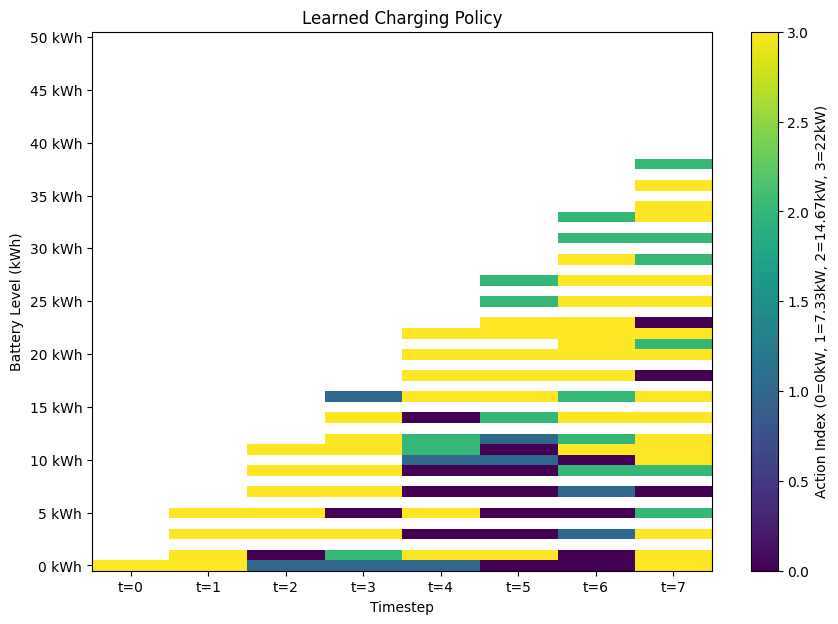

In [8]:
#| label: fig-policy-heatmap
#| fig-cap: "Learned Charging Policy"
plot_policy_heatmap(agent.q_table, env.action_space)

In [42]:
# Evaluation Function - Assessing the learned policy over multiple simulated days
def evaluate_smart_charging(env, agent, test_episodes=1000):
    print(f"\n--- Starting Evaluation over {test_episodes} simulated days ---")
    
    # Turn off exploration (Pure Exploitation)
    agent.epsilon = 0.0 
    
    failures = 0
    total_charging_cost = 0.0
    
    for _ in range(test_episodes):
        state = env.reset()
        done = False
        episode_cost = 0.0
        
        while not done:
            # Always choose the optimal known action
            action_idx = np.argmax(agent.q_table[state])
            next_state, reward, done = env.step(action_idx)
            
            # If the reward is massive negative, it hit the penalty, not just a cost
            if reward > -500: 
                # Cost is the absolute value of the negative reward
                episode_cost += abs(reward) 
            
            if done and reward <= -500:
                failures += 1
                
            state = next_state
            
        # Only add to average cost if the agent didn't fail
        if reward > -500:
            total_charging_cost += episode_cost
            
    # 3. Calculate Final Metrics
    successful_days = test_episodes - failures
    success_rate = (successful_days / test_episodes) * 100
    avg_cost = total_charging_cost / successful_days if successful_days > 0 else 0
    
    print(f"Success Rate (Shift demand met): {success_rate:.2f}%")
    print(f"Failure Rate (Ran out of energy): {(failures/test_episodes)*100:.2f}%")
    if successful_days > 0:
         print(f"Average Charging Cost per day: ${avg_cost:.2f}")
    else:
         print("Agent failed every single day. No average cost calculated.")


# Baseline: Naive Strategy (Always charge at max power)
def calculate_naive_baseline(env, test_episodes=1000):
    print(f"\n--- Calculating Naive Strategy Baseline ({test_episodes} days) ---")
    
    total_naive_cost = 0.0
    failures = 0
    
    # The action index for 22 kW is the last index in the action space
    max_power_action_idx = len(env.action_space) - 1
    
    for _ in range(test_episodes):
        env.reset()
        done = False
        episode_cost = 0.0
        
        while not done:
            # The Naive Agent completely ignores the state and Q-table
            # It just blasts maximum power every single time
            next_state, reward, done = env.step(max_power_action_idx)
            
            if reward > -500: 
                episode_cost += abs(reward)
                
            if done and reward <= -500:
                failures += 1
                
        if reward > -500:
            total_naive_cost += episode_cost

    successful_days = test_episodes - failures
    success_rate = (successful_days / test_episodes) * 100
    avg_cost = total_naive_cost / successful_days if successful_days > 0 else 0
    
    print(f"Naive Success Rate: {success_rate:.2f}%")
    if successful_days > 0:
         print(f"Average Naive Charging Cost per day: ${avg_cost:.2f}")

In [43]:
# Run the evaluation
evaluate_smart_charging(env, agent, test_episodes=1000)

# Run the baseline
calculate_naive_baseline(env, test_episodes=1000)


--- Starting Evaluation over 1000 simulated days ---
Success Rate (Shift demand met): 95.90%
Failure Rate (Ran out of energy): 4.10%
Average Charging Cost per day: $1.77

--- Calculating Naive Strategy Baseline (1000 days) ---
Naive Success Rate: 99.80%
Average Naive Charging Cost per day: $1.92


In [ ]:
# TODO: Consider adding more sophisticated baselines, such as:
# - A rule-based strategy that charges at a moderate power level (e.g., 10 kW) regardless of the state

# TODO: Create fucntion to run multiple simulations with different random seeds to assess 
# the robustness of the learned policy and baseline strategies.

# TODO: Create Deep Q-Network (DQN) agent for comparison, which can handle continuous state spaces and 
# potentially learn more complex policies.